In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aclark108a/healthcare-analytics-project/provider_performance_dataset.csv
/kaggle/input/datasets/aclark108a/healthcare-analytics-project/department_costs_dataset.csv
/kaggle/input/datasets/aclark108a/healthcare-analytics-project/healthcare_claims_dataset.csv


# Healthcare Claims Analytics Project

## SQL, Python, and Tableau Healthcare Analytics Portfolio Project

### Objective
This project analyzes healthcare insurance claims data to identify:

- Claim approval trends
- Provider performance
- Departmental healthcare costs
- Insurance payment trends
- Financial healthcare insights

### Tools Used
- Python
- SQL (SQLite)
- Pandas
- Matplotlib
- Kaggle Notebooks
- Tableau Public

In [2]:
import pandas as pd
import sqlite3

# Data Loading and Cleaning

In this section:

- The healthcare claims dataset is loaded
- Data quality checks are performed
- Missing values and data types are reviewed
- Date formatting is completed

In [3]:
df = pd.read_csv('/kaggle/input/datasets/aclark108a/healthcare-analytics-project/healthcare_claims_dataset.csv')

df.head()

,Claim_ID,Patient_ID,Provider_ID,Department,Insurance_Provider,Provider_Specialty,Service_Date,Claim_Status,Billed_Amount,Paid_Amount,Length_of_Stay,Patient_Age
0,1,42098,257,Neurology,Cigna,Physician,2024-11-23,Denied,2872.14,0.00,11,70
1,2,40495,329,Oncology,Medicare,Nurse Practitioner,2024-02-14,Approved,14803.26,10778.38,12,84
2,3,10851,240,Emergency,Aetna,Surgeon,2024-12-25,Approved,13669.04,11984.74,5,20
3,4,22676,291,Radiology,Blue Cross,Surgeon,2024-04-20,Approved,23934.61,17420.18,13,6
4,5,20328,341,Orthopedics,Cigna,Surgeon,2025-01-08,Approved,11539.68,11270.67,10,25


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Claim_ID            5000 non-null   int64  
 1   Patient_ID          5000 non-null   int64  
 2   Provider_ID         5000 non-null   int64  
 3   Department          5000 non-null   object 
 4   Insurance_Provider  5000 non-null   object 
 5   Provider_Specialty  5000 non-null   object 
 6   Service_Date        5000 non-null   object 
 7   Claim_Status        5000 non-null   object 
 8   Billed_Amount       5000 non-null   float64
 9   Paid_Amount         5000 non-null   float64
 10  Length_of_Stay      5000 non-null   int64  
 11  Patient_Age         5000 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 468.9+ KB


In [5]:
df['Service_Date'] = pd.to_datetime(df['Service_Date'])

# SQL Healthcare Claims Analysis

The dataset is converted into a SQLite database table so SQL queries can be executed directly inside the notebook.

The SQL analysis focuses on:

- Insurance claim approval rates
- Department healthcare costs
- Provider performance metrics
- Financial healthcare trends

In [6]:
conn = sqlite3.connect(':memory:')

df.to_sql(
    'healthcare_claims',
    conn,
    index=False,
    if_exists='replace'
)

5000

In [7]:
query = """

SELECT
    Insurance_Provider,
    COUNT(*) AS Total_Claims,
    
    SUM(
        CASE
            WHEN Claim_Status = 'Approved'
            THEN 1
            ELSE 0
        END
    ) AS Approved_Claims,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN Claim_Status = 'Approved'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS Approval_Rate

FROM healthcare_claims

GROUP BY Insurance_Provider

ORDER BY Approval_Rate DESC

"""

pd.read_sql(query, conn)

,Insurance_Provider,Total_Claims,Approved_Claims,Approval_Rate
0,Blue Cross,833,602,72.27
1,Cigna,867,617,71.16
2,Medicare,792,560,70.71
3,United Healthcare,803,556,69.24
4,Medicaid,842,583,69.24
5,Aetna,863,593,68.71


In [8]:
query = """

SELECT
    Department,
    SUM(Billed_Amount) AS Total_Billed,
    SUM(Paid_Amount) AS Total_Paid

FROM healthcare_claims

GROUP BY Department

ORDER BY Total_Billed DESC

"""

pd.read_sql(query, conn)

,Department,Total_Billed,Total_Paid
0,Emergency,9730252.52,6208175.97
1,Pediatrics,9284176.99,5915998.84
2,Radiology,9112094.25,5770516.81
3,Neurology,9103203.40,5983808.34
4,Oncology,8734421.80,5659012.38
5,Cardiology,8540072.84,5706993.60
6,Orthopedics,8000617.62,5170007.26


In [9]:
query = """

SELECT
    Provider_ID,
    COUNT(*) AS Total_Claims,
    AVG(Billed_Amount) AS Avg_Billed,
    AVG(Paid_Amount) AS Avg_Paid

FROM healthcare_claims

GROUP BY Provider_ID

ORDER BY Avg_Paid DESC

LIMIT 10

"""

pd.read_sql(query, conn)

,Provider_ID,Total_Claims,Avg_Billed,Avg_Paid
0,223,38,14494.675526,10748.535000
1,337,36,15021.602778,10739.438611
2,327,34,14502.412353,10685.600882
3,200,37,15398.131081,10675.244595
4,349,34,14917.284412,10463.448824
5,266,28,14686.511786,10127.071786
6,275,21,12719.911905,10032.853810
7,262,32,13804.821250,10003.143750
8,348,37,13461.635135,9900.837838
9,344,35,13660.830857,9745.131143


In [10]:
query = """

SELECT
    Provider_ID,
    COUNT(*) AS Total_Claims,
    AVG(Billed_Amount) AS Avg_Billed,
    AVG(Paid_Amount) AS Avg_Paid

FROM healthcare_claims

GROUP BY Provider_ID

ORDER BY Avg_Paid DESC

LIMIT 10

"""

pd.read_sql(query, conn)

,Provider_ID,Total_Claims,Avg_Billed,Avg_Paid
0,223,38,14494.675526,10748.535000
1,337,36,15021.602778,10739.438611
2,327,34,14502.412353,10685.600882
3,200,37,15398.131081,10675.244595
4,349,34,14917.284412,10463.448824
5,266,28,14686.511786,10127.071786
6,275,21,12719.911905,10032.853810
7,262,32,13804.821250,10003.143750
8,348,37,13461.635135,9900.837838
9,344,35,13660.830857,9745.131143


# Healthcare Data Visualizations

Visualizations are created to better understand trends and patterns within the healthcare claims dataset.

The charts analyze:

- Claim approval rates
- Departmental healthcare costs
- Insurance provider payment trends
- Financial healthcare metrics

In [11]:
import matplotlib.pyplot as plt

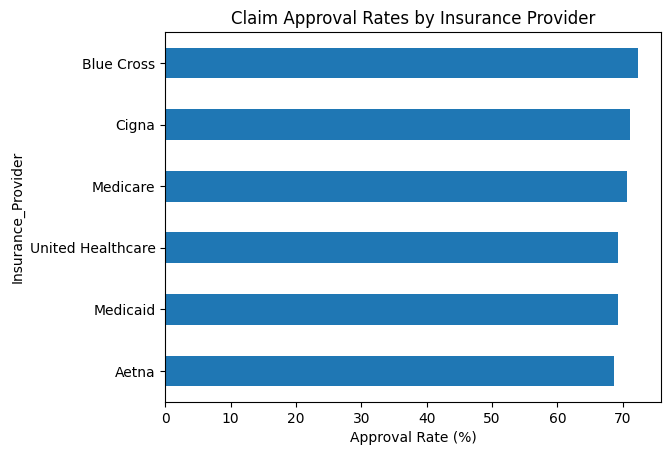

In [12]:
approval_rates = df.groupby('Insurance_Provider')['Claim_Status'] \
    .apply(lambda x: (x == 'Approved').mean() * 100)

approval_rates.sort_values().plot(kind='barh')

plt.title('Claim Approval Rates by Insurance Provider')
plt.xlabel('Approval Rate (%)')

plt.show()

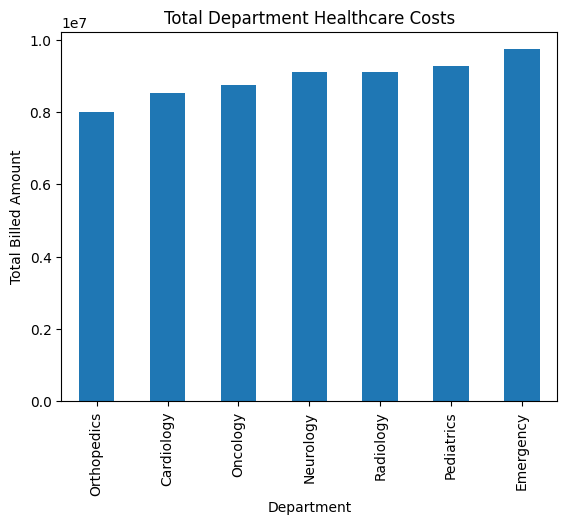

In [13]:
dept_costs = df.groupby('Department')['Billed_Amount'].sum()

dept_costs.sort_values().plot(kind='bar')

plt.title('Total Department Healthcare Costs')
plt.ylabel('Total Billed Amount')

plt.show()

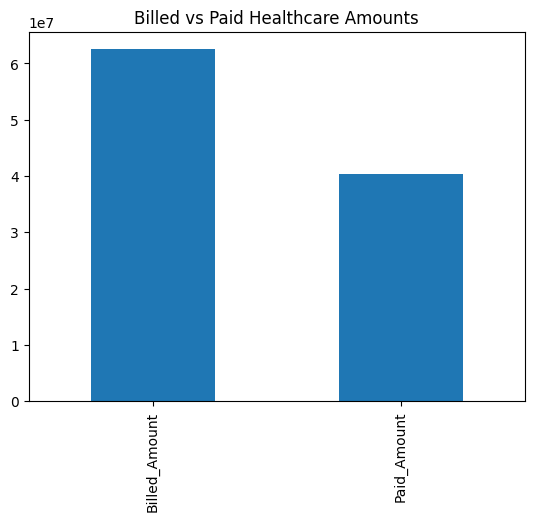

In [14]:
totals = df[['Billed_Amount', 'Paid_Amount']].sum()

totals.plot(kind='bar')

plt.title('Billed vs Paid Healthcare Amounts')

plt.show()

# Final Business Insights

## Key Findings

### Insurance Trends
- Insurance approval rates vary across providers.
- Some insurers demonstrate higher claim approval percentages.

### Department Costs
- Certain departments generate higher healthcare costs.
- Department spending trends support operational budgeting analysis.

### Provider Performance
- Provider payment averages differ significantly.
- High-performing providers manage larger claim volumes.

## Business Value

This project demonstrates how healthcare analytics can support:

- Financial healthcare analysis
- Insurance performance tracking
- Healthcare cost management
- Operational decision-making

# Project Summary

This healthcare analytics portfolio project was developed using:

- SQL
- Python
- Kaggle
- Tableau Public

The project analyzed:
- 5,000+ healthcare insurance claims
- Insurance approval trends
- Provider performance metrics
- Department healthcare costs

The analysis included:
- SQL querying
- Data cleaning
- Python visualization
- Business intelligence reporting